# Mental Health Prediction: EDA и подготовка данных

Исследуем данные, выполняем фиксированную очистку и сохраняем train, val и test в data/preprocessed.

Следующий этап - сравнение моделей в [2_models.ipynb](2_models.ipynb).


## 1. Загрузка данных и настройки


In [24]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

PROJECT_DIR = Path("data_science_project") if Path("data_science_project").is_dir() else Path(".")
DATA_DIR = PROJECT_DIR / "data/raw"
PREPROCESSED_DIR = PROJECT_DIR / "data/preprocessed"
RANDOM_STATE = 56
TARGET = "Depression"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

train = pd.read_csv(DATA_DIR / "train.csv")
kaggle_test = pd.read_csv(DATA_DIR / "test.csv")

pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(kaggle_test)],
    "columns": [train.shape[1], kaggle_test.shape[1]],
})


,dataset,rows,columns
0,train,140700,20
1,test,93800,19


## 2. Паспорт и качество данных

In [25]:
def column_profile(frame: pd.DataFrame) -> pd.DataFrame:
    profile = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "missing": frame.isna().sum(),
        "missing_pct": frame.isna().mean().mul(100),
        "unique": frame.nunique(dropna=False),
    })
    return profile.sort_values(["missing_pct", "unique"], ascending=[False, True])

display(train)
display(column_profile(train).round(2))

train_only_columns = sorted(set(train.columns) - set(kaggle_test.columns))
test_only_columns = sorted(set(kaggle_test.columns) - set(train.columns))
print("Только в train:", train_only_columns)
print("Только в test:", test_only_columns)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,140695,Vidya,Female,18.0,Ahmedabad,Working Professional,NaN,NaN,5.0,NaN,NaN,4.0,5-6 hours,Unhealthy,Class 12,No,2.0,4.0,Yes,1
140696,140696,Lata,Female,41.0,Hyderabad,Working Professional,Content Writer,NaN,5.0,NaN,NaN,4.0,7-8 hours,Moderate,B.Tech,Yes,6.0,5.0,Yes,0
140697,140697,Aanchal,Female,24.0,Kolkata,Working Professional,Marketing Manager,NaN,3.0,NaN,NaN,1.0,More than 8 hours,Moderate,B.Com,No,4.0,4.0,No,0
140698,140698,Prachi,Female,49.0,Srinagar,Working Professional,Plumber,NaN,5.0,NaN,NaN,2.0,5-6 hours,Moderate,ME,Yes,10.0,1.0,No,0


,dtype,missing,missing_pct,unique
Academic Pressure,float64,112803,80.17,6
Study Satisfaction,float64,112803,80.17,6
CGPA,float64,112802,80.17,332
Profession,str,36630,26.03,65
Work Pressure,float64,27918,19.84,6
Job Satisfaction,float64,27910,19.84,6
Financial Stress,float64,4,0.00,6
Dietary Habits,str,4,0.00,24
Degree,str,2,0.00,116
Gender,str,0,0.00,2


Только в train: ['Depression']
Только в test: []


In [26]:
num_cols = list(train.select_dtypes(include=[int, float]).columns)
print('Числовые столбцы:', len(num_cols), (num_cols))

cat_cols = list(train.select_dtypes(include=['str']).columns)
print('Категориальные столбцы:', len(cat_cols), (cat_cols))

Числовые столбцы: 10 ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']
Категориальные столбцы: 10 ['Name', 'Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


### Дубликаты и идентификаторы

Полные строки могут быть уникальными только из-за `id` или имени. Поэтому дополнительно проверяем дубликаты по содержательным признакам.

In [27]:
feature_columns_for_duplicates = [
    column for column in train.columns if column not in {"id", "Name", TARGET}
]

duplicate_summary = pd.Series({
    "Полные дубликаты": int(train.duplicated().sum()),
    "Дубликаты без id и Name": int(train.duplicated(feature_columns_for_duplicates).sum()),
    "Дубликаты id в train": int(train["id"].duplicated().sum()),
    "Пересечение id train/test": int(len(set(train["id"]) & set(kaggle_test["id"]))),
})
display(duplicate_summary.to_frame("count"))

,count
Полные дубликаты,0
Дубликаты без id и Name,5
Дубликаты id в train,0
Пересечение id train/test,0


## 3. Целевая переменная

Accuracy является метрикой соревнования на Kaggle, но при дисбалансе ее недостаточно. На этапе моделирования также потребуются Precision, Recall, F1, ROC-AUC и PR-AUC.

,count,share
Depression,,
0,115133,81.83%
1,25567,18.17%


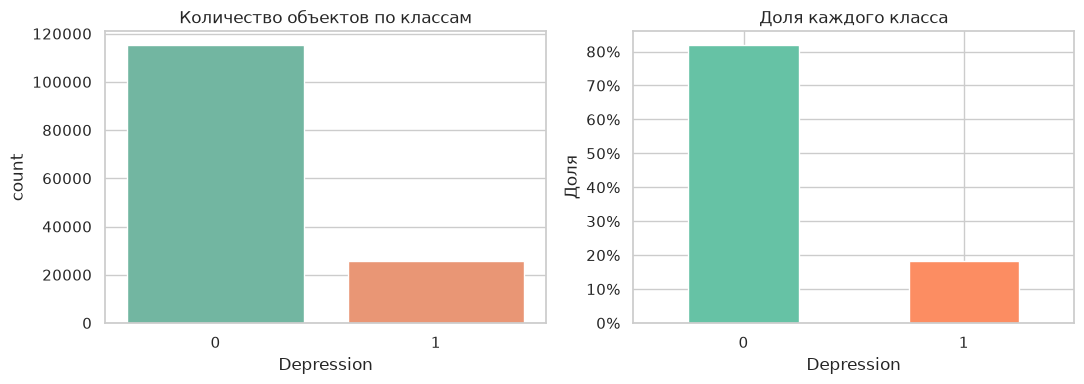

In [28]:
target_stats = train[TARGET].value_counts().sort_index().rename("count").to_frame()
target_stats["share"] = target_stats["count"] / len(train)
display(target_stats.style.format({"share": "{:.2%}"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=train, x=TARGET, ax=axes[0], hue=TARGET, legend=False, palette="Set2")
axes[0].set_title("Количество объектов по классам")
target_stats["share"].plot.bar(ax=axes[1], color=sns.color_palette("Set2", 2))
axes[1].set_title("Доля каждого класса")
axes[1].set_ylabel("Доля")
axes[1].tick_params(axis="x", rotation=0)
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

## 4. Пропуски

Особенно важно проверить, являются ли пропуски случайными

,missing,missing_share
Academic Pressure,112803.000000,80.17%
Study Satisfaction,112803.000000,80.17%
CGPA,112802.000000,80.17%
Profession,36630.000000,26.03%
Work Pressure,27918.000000,19.84%
Job Satisfaction,27910.000000,19.84%
Dietary Habits,4.000000,0.00%
Financial Stress,4.000000,0.00%
Degree,2.000000,0.00%


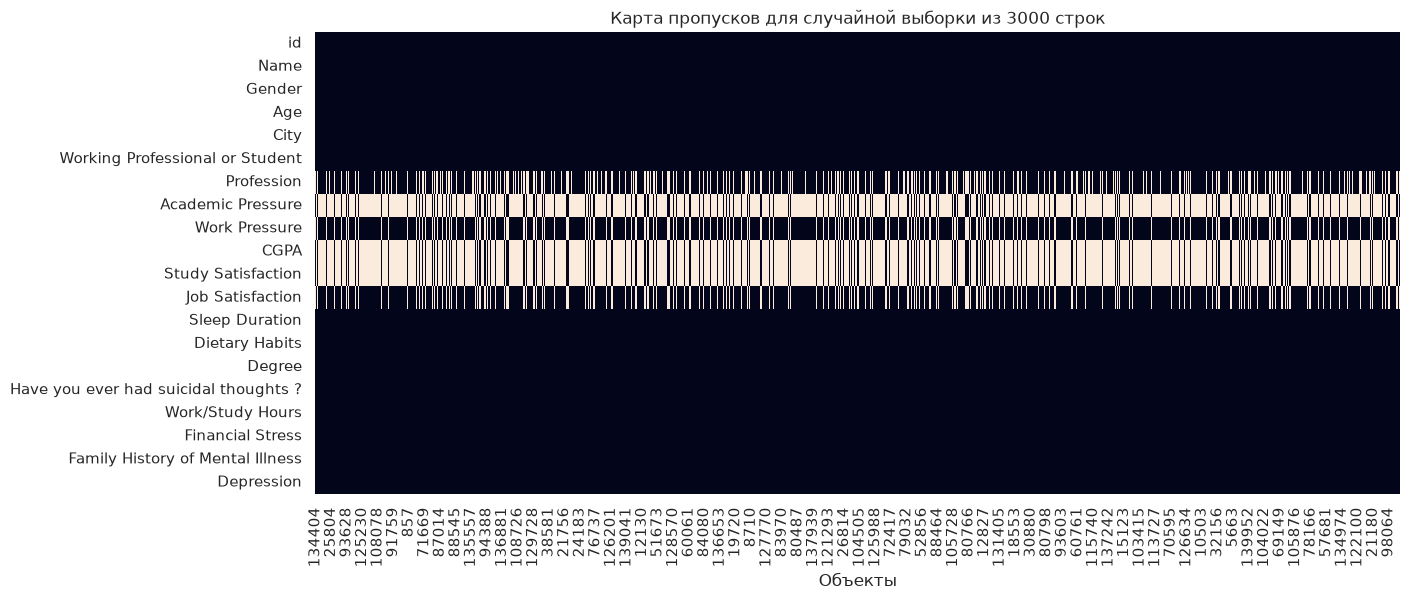

In [29]:
missing_summary = (
    train.isna().agg(["sum", "mean"]).T
    .rename(columns={"sum": "missing", "mean": "missing_share"})
    .query("missing > 0")
    .sort_values("missing_share", ascending=False)
)
display(missing_summary.style.format({"missing_share": "{:.2%}"}))

sample_size = min(3000, len(train))
missing_sample = train.sample(sample_size, random_state=RANDOM_STATE).isna().T
plt.figure(figsize=(14, 6))
sns.heatmap(missing_sample, cbar=False, yticklabels=True)
plt.title(f"Карта пропусков для случайной выборки из {sample_size} строк")
plt.xlabel("Объекты")
plt.show()

In [30]:
ROLE_COLUMN = "Working Professional or Student"
ACADEMIC_COLUMNS = ["Academic Pressure", "CGPA", "Study Satisfaction"]
WORK_COLUMNS = ["Work Pressure", "Job Satisfaction"]
ROLE_SPECIFIC_COLUMNS = ACADEMIC_COLUMNS + WORK_COLUMNS

missing_by_role = (
    train.groupby(ROLE_COLUMN, observed=True)[ROLE_SPECIFIC_COLUMNS]
    .agg(lambda series: series.isna().mean())
    .T.mul(100)
)
display(missing_by_role.style.format("{:.1f}%").background_gradient(cmap="Reds", vmin=0, vmax=100))

target_by_role = (
    train.groupby(ROLE_COLUMN, observed=True)[TARGET]
    .agg(count="size", positive="sum", target_rate="mean")
    .sort_values("target_rate", ascending=False)
)
display(target_by_role.style.format({"target_rate": "{:.2%}"}))

Working Professional or Student,Student,Working Professional
Academic Pressure,0.0%,100.0%
CGPA,0.0%,100.0%
Study Satisfaction,0.0%,100.0%
Work Pressure,100.0%,0.0%
Job Satisfaction,100.0%,0.0%


,count,positive,target_rate
Working Professional or Student,,,
Student,27901,16336,58.55%
Working Professional,112799,9231,8.18%


**Вывод по пропускам.** Пропуски в учебных и рабочих признаках структурные. Для CatBoost и LightGBM оставляем их как NaN. Для LR и RF перед заполнением сохраняем отдельные индикаторы пропусков. Медианы и масштабирование рассчитываются на обучающей части каждого фолда.


## 5. Категориальные признаки

Для сравнения категорий используем не только количество объектов, но и долю положительного класса. Редкие категории скрываются с графиков, но отдельно учитываются в таблице качества данных.

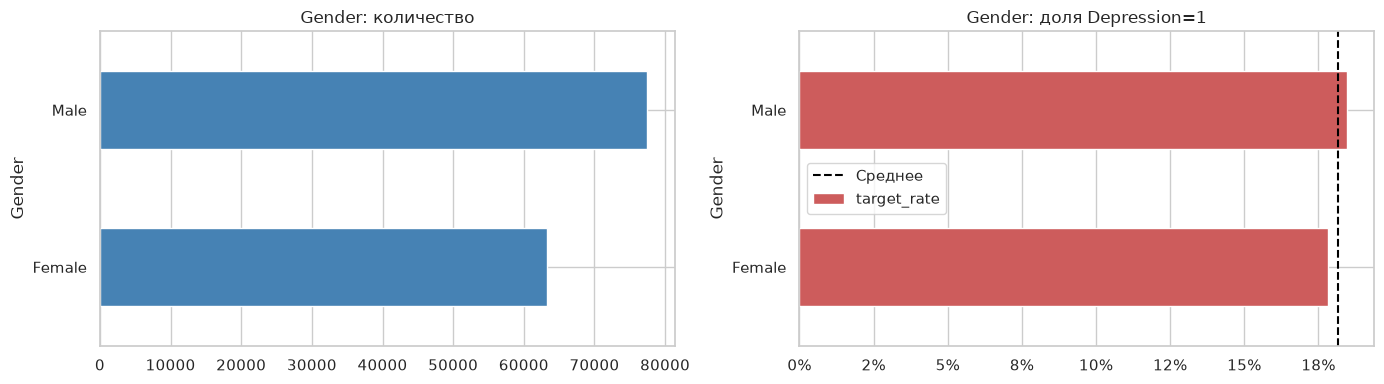

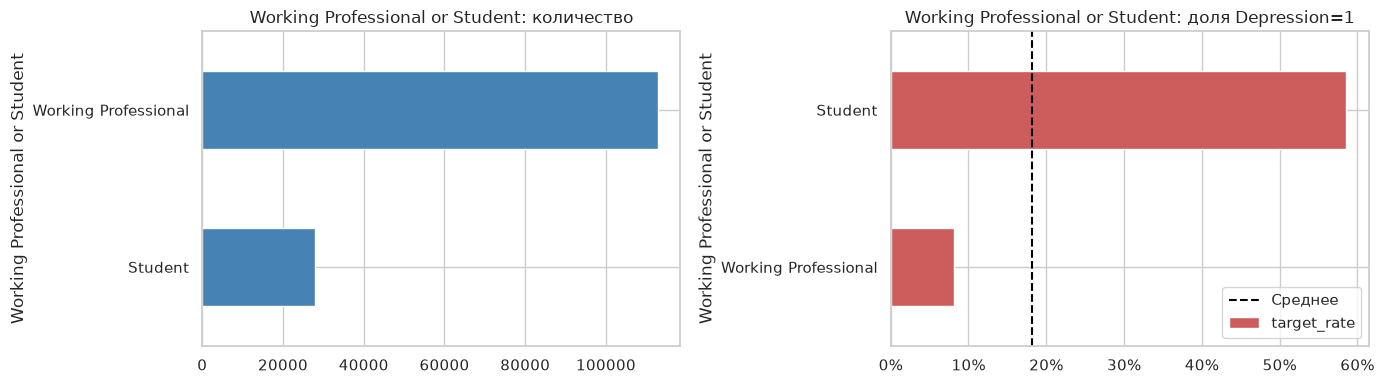

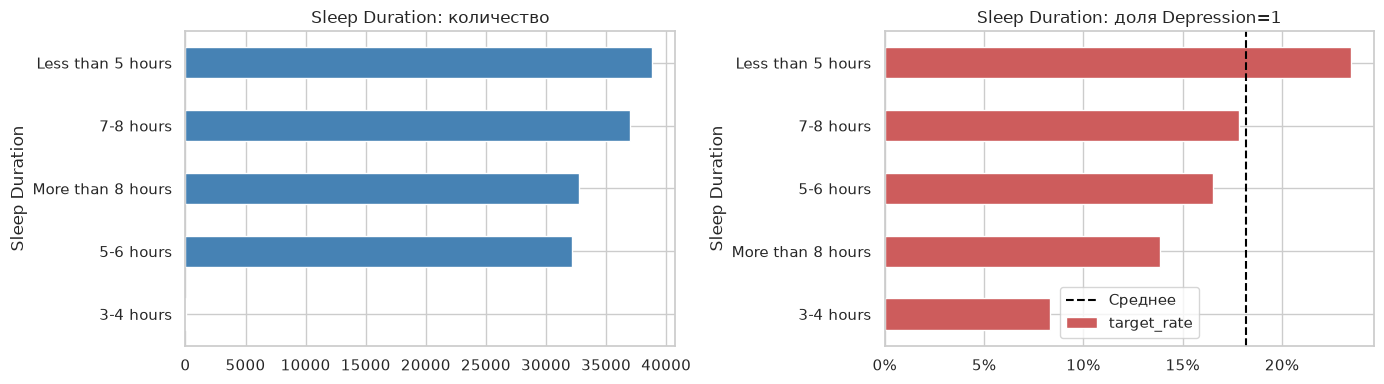

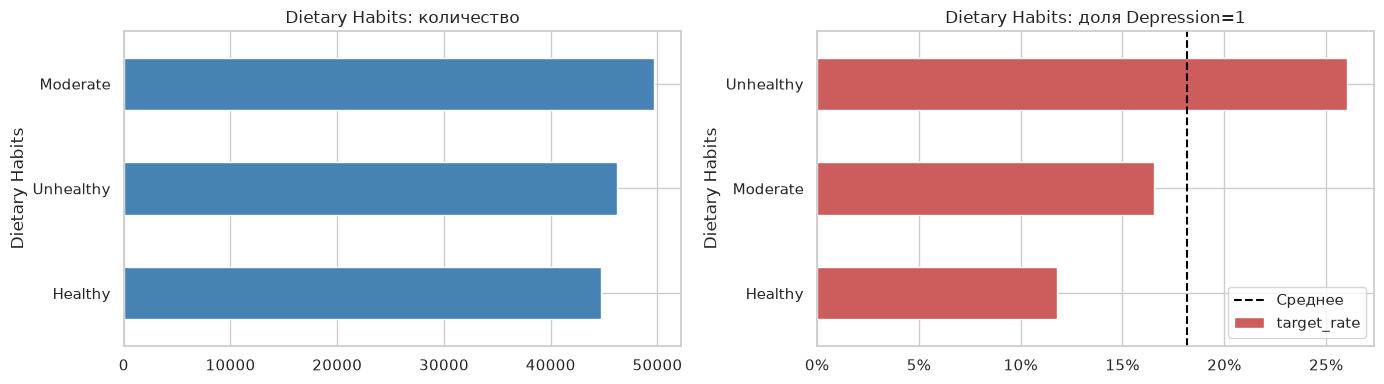

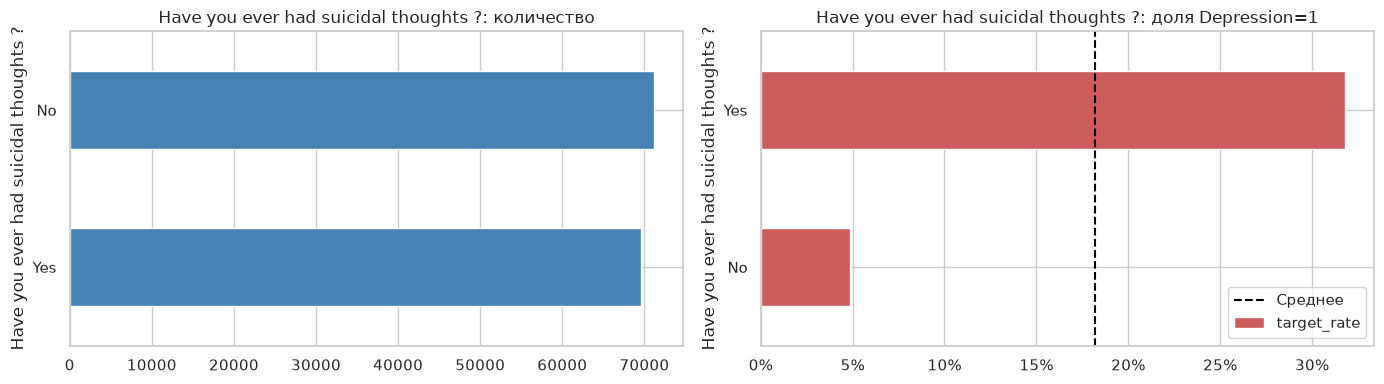

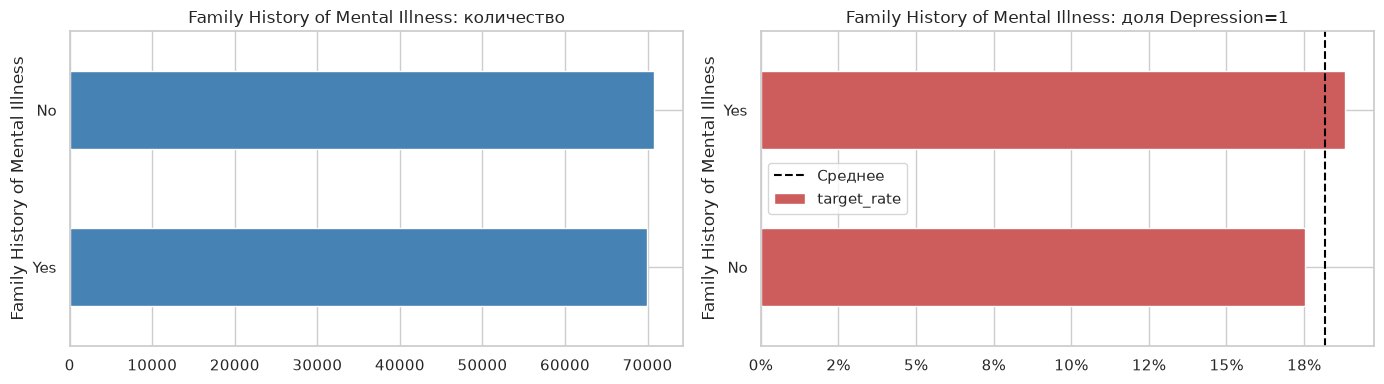

In [37]:
categorical_columns = [
    column for column in train.select_dtypes(include=["str", "object", "category"]).columns
    if column != "Name"
]

def categorical_target_summary(
    frame: pd.DataFrame,
    column: str,
    target: str = TARGET,
    min_count: int = 1,
    max_count: int = 1e8
) -> pd.DataFrame:
    prepared = frame[[column, target]].copy()
    prepared[column] = prepared[column].fillna("<NA>").astype(str)
    summary = (
        prepared.groupby(column, observed=True)[target]
        .agg(count="size", target_rate="mean")
        .query("count >= @min_count and count <= @max_count")
        .sort_values("target_rate", ascending=False)
    )
    return summary

def plot_categorical_target(
    frame: pd.DataFrame,
    column: str,
    min_count: int = 1,
    max_categories: int = 30,
    max_count: int = 1e8
) -> None:
    summary = categorical_target_summary(frame, column, min_count=min_count, max_count=max_count)
    if len(summary) > max_categories:
        largest = summary.nlargest(max_categories, "count").index
        summary = summary.loc[largest].sort_values("target_rate", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(summary) * 0.28)))
    summary.sort_values("count")["count"].plot.barh(ax=axes[0], color="steelblue")
    summary.sort_values("target_rate")["target_rate"].plot.barh(ax=axes[1], color="indianred")
    
    axes[0].set_title(f"{column}: количество")
    axes[1].set_title(f"{column}: доля Depression=1")
    axes[1].axvline(frame[TARGET].mean(), color="black", linestyle="--", label="Среднее")
    axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

key_categorical_columns = [
    "Gender",
    ROLE_COLUMN,
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness",
]
for column in key_categorical_columns:
    plot_categorical_target(train, column, min_count=10)

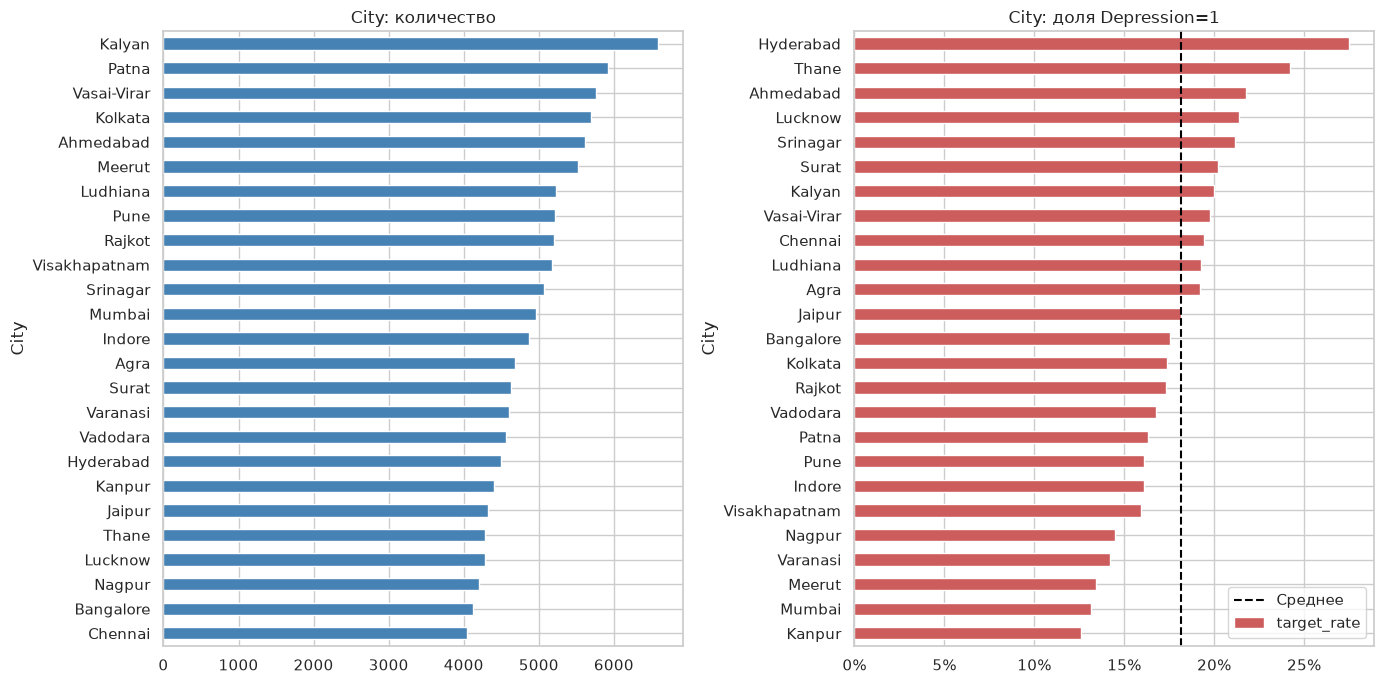

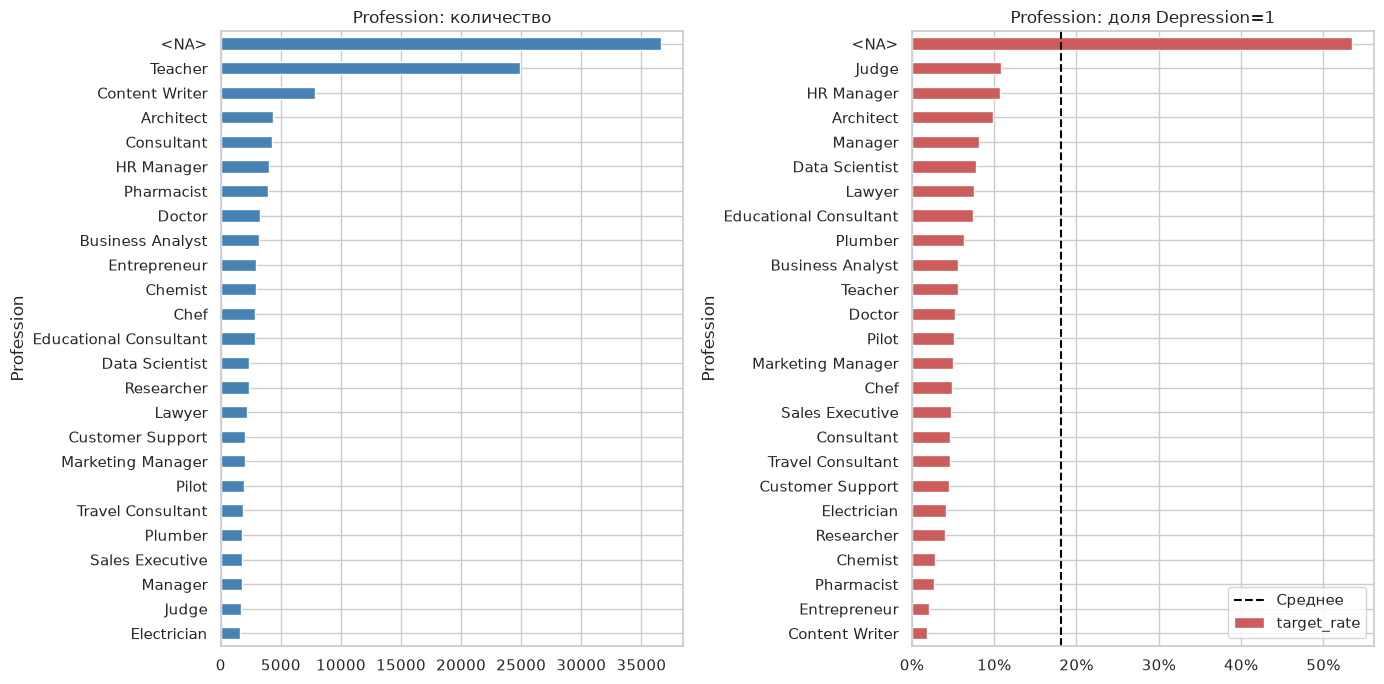

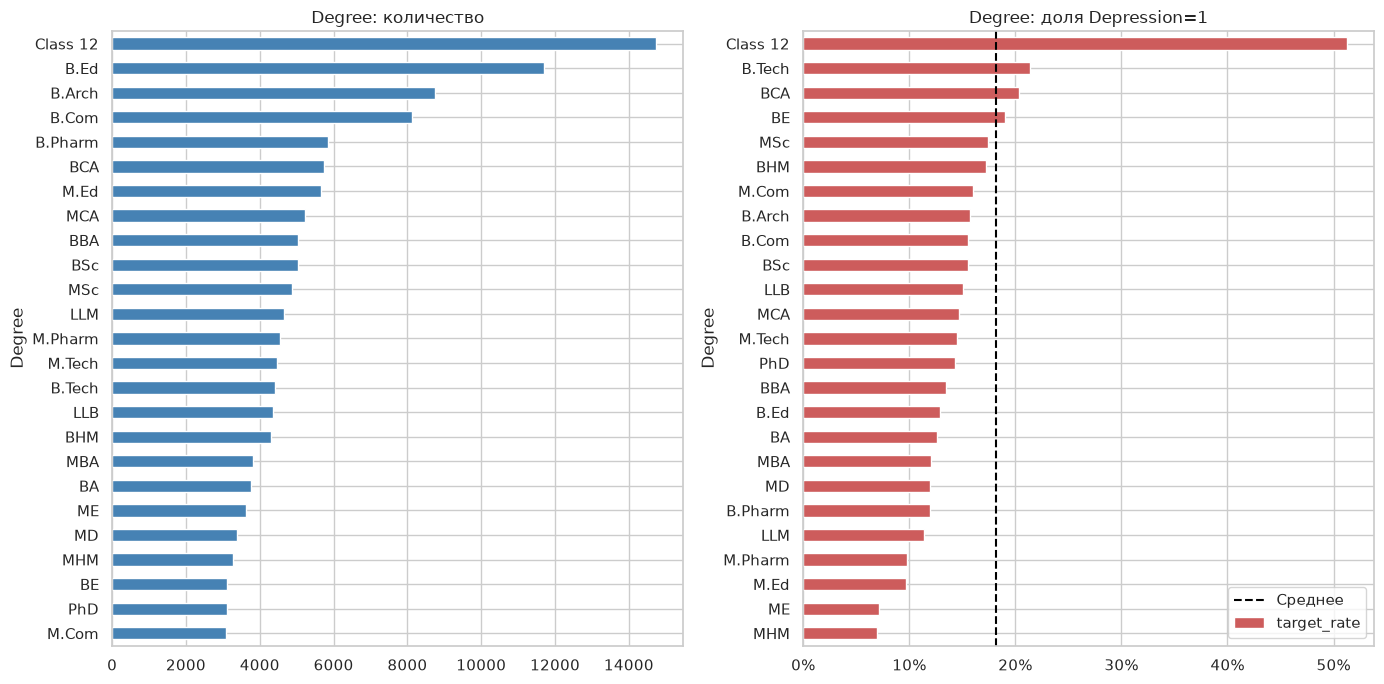

In [32]:
high_cardinality_columns = ["City", "Profession", "Degree"]
for column in high_cardinality_columns:
    plot_categorical_target(train, column, min_count=100, max_categories=25)


### Редкий хвост категорий

Таблица описывает частоты исходных значений

In [33]:
rare_category_rows = []
for column in categorical_columns:
    counts = train[column].fillna("<NA>").astype(str).value_counts()
    rare = counts[counts < 5]
    rare_category_rows.append({
        "column": column,
        "categories": len(counts),
        "rare_categories_lt_5": len(rare),
        "rows_in_rare_categories": int(rare.sum()),
        "examples": ", ".join(rare.index[:8]),
    })
display(pd.DataFrame(rare_category_rows).sort_values("rare_categories_lt_5", ascending=False))

,column,categories,rare_categories_lt_5,rows_in_rare_categories,examples
6,Degree,116,88,111,"UX/UI Designer, B.Sc, M, Kalyan, Nalini, BEd, ..."
1,City,98,67,91,"Nandini, Harsha, Saanvi, Bhavna, Pratyush, Cit..."
3,Profession,65,27,38,"Unemployed, Yogesh, BCA, Profession, MBA, LLM,..."
4,Sleep Duration,36,27,42,"6-8 hours, 1-6 hours, No, Sleep_Duration, 10-1..."
5,Dietary Habits,24,21,27,"<NA>, Yes, More Healthy, No, Pratham, BSc, Gen..."
0,Gender,2,0,0,
2,Working Professional or Student,2,0,0,
7,Have you ever had suicidal thoughts ?,2,0,0,
8,Family History of Mental Illness,2,0,0,


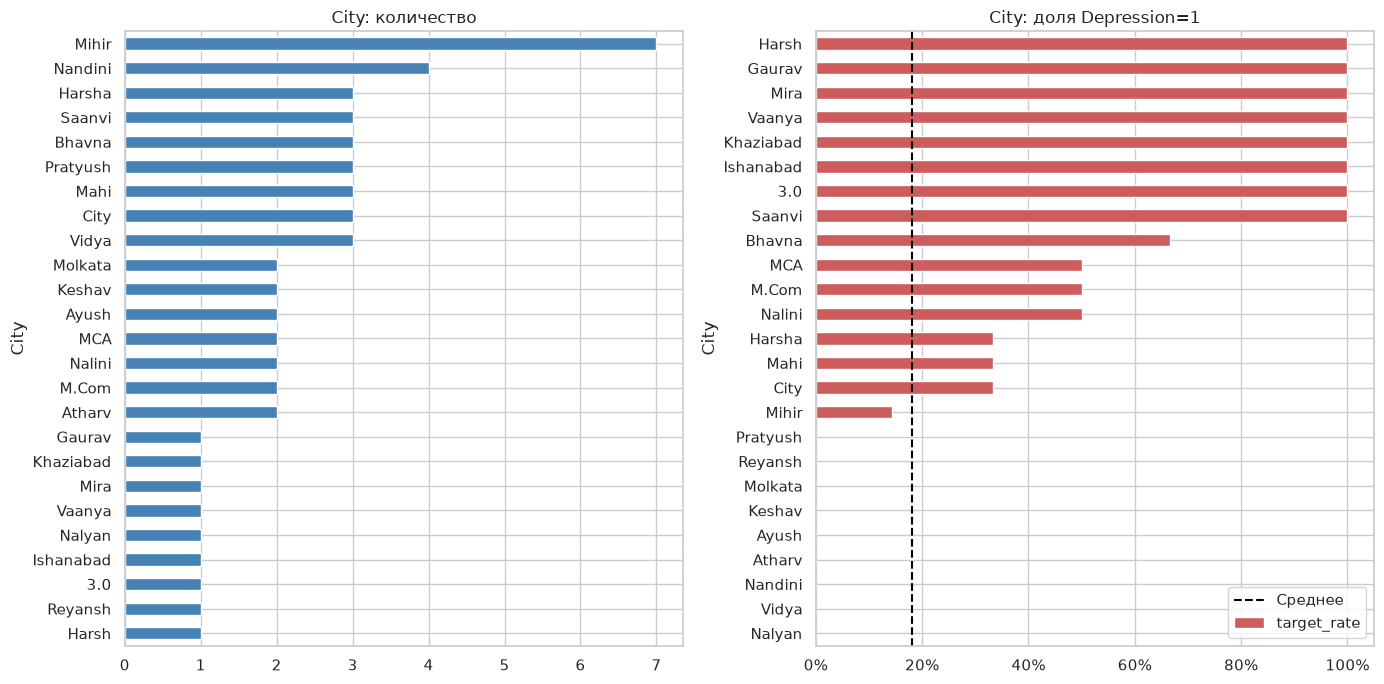

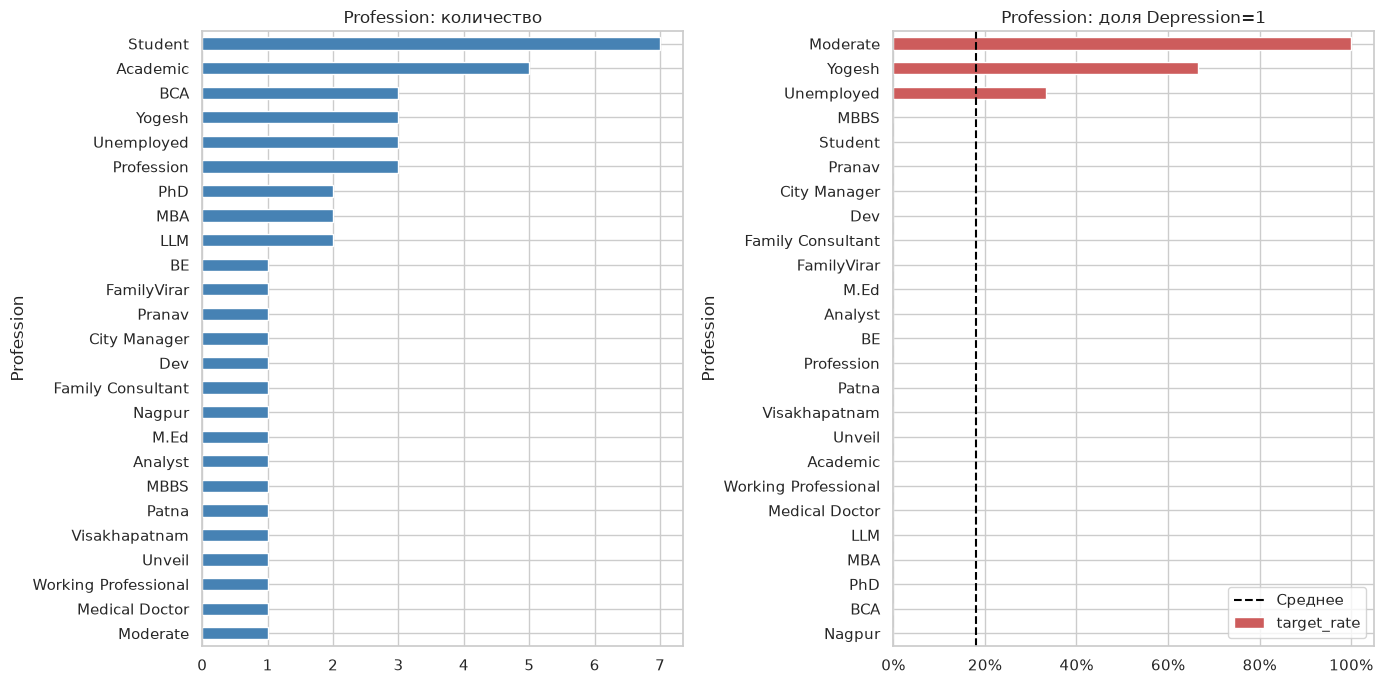

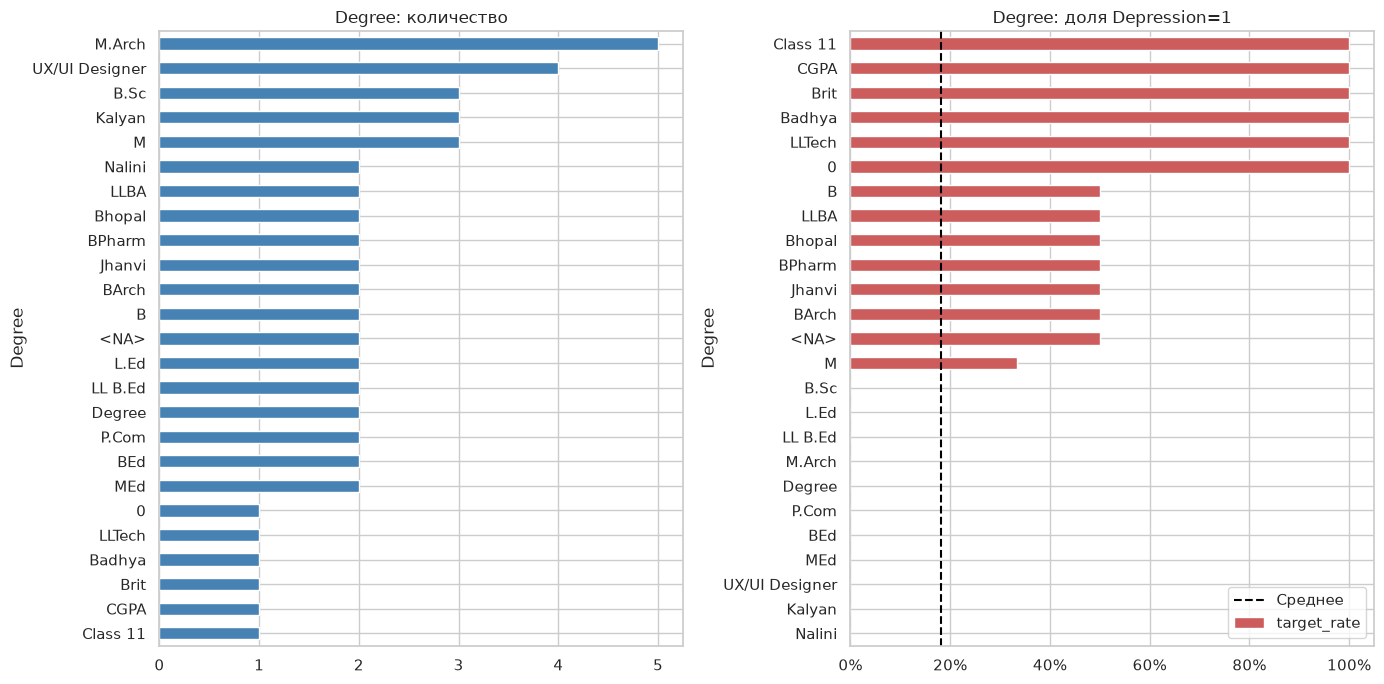

In [51]:
high_cardinality_columns = ["City", "Profession", "Degree"]
for column in high_cardinality_columns:
    plot_categorical_target(train, column, min_count=1, max_count=300, max_categories=25)

## 6. Числовые признаки и выбросы

Для порядковых шкал 1-5 правило IQR не всегда содержательно, поэтому дополнительно проверяем диапазоны, заданные смыслом признаков.

,count,mean,std,min,25%,50%,75%,max
Age,140700.0,40.388621,12.384099,18.00,29.00,42.00,51.00,60.0
Academic Pressure,27897.0,3.142273,1.380457,1.00,2.00,3.00,4.00,5.0
Work Pressure,112782.0,2.998998,1.405771,1.00,2.00,3.00,4.00,5.0
CGPA,27898.0,7.658636,1.464466,5.03,6.29,7.77,8.92,10.0
Study Satisfaction,27897.0,2.944940,1.360197,1.00,2.00,3.00,4.00,5.0
Job Satisfaction,112790.0,2.974404,1.416078,1.00,2.00,3.00,4.00,5.0
Work/Study Hours,140700.0,6.252679,3.853615,0.00,3.00,6.00,10.00,12.0
Financial Stress,140696.0,2.988983,1.413633,1.00,2.00,3.00,4.00,5.0


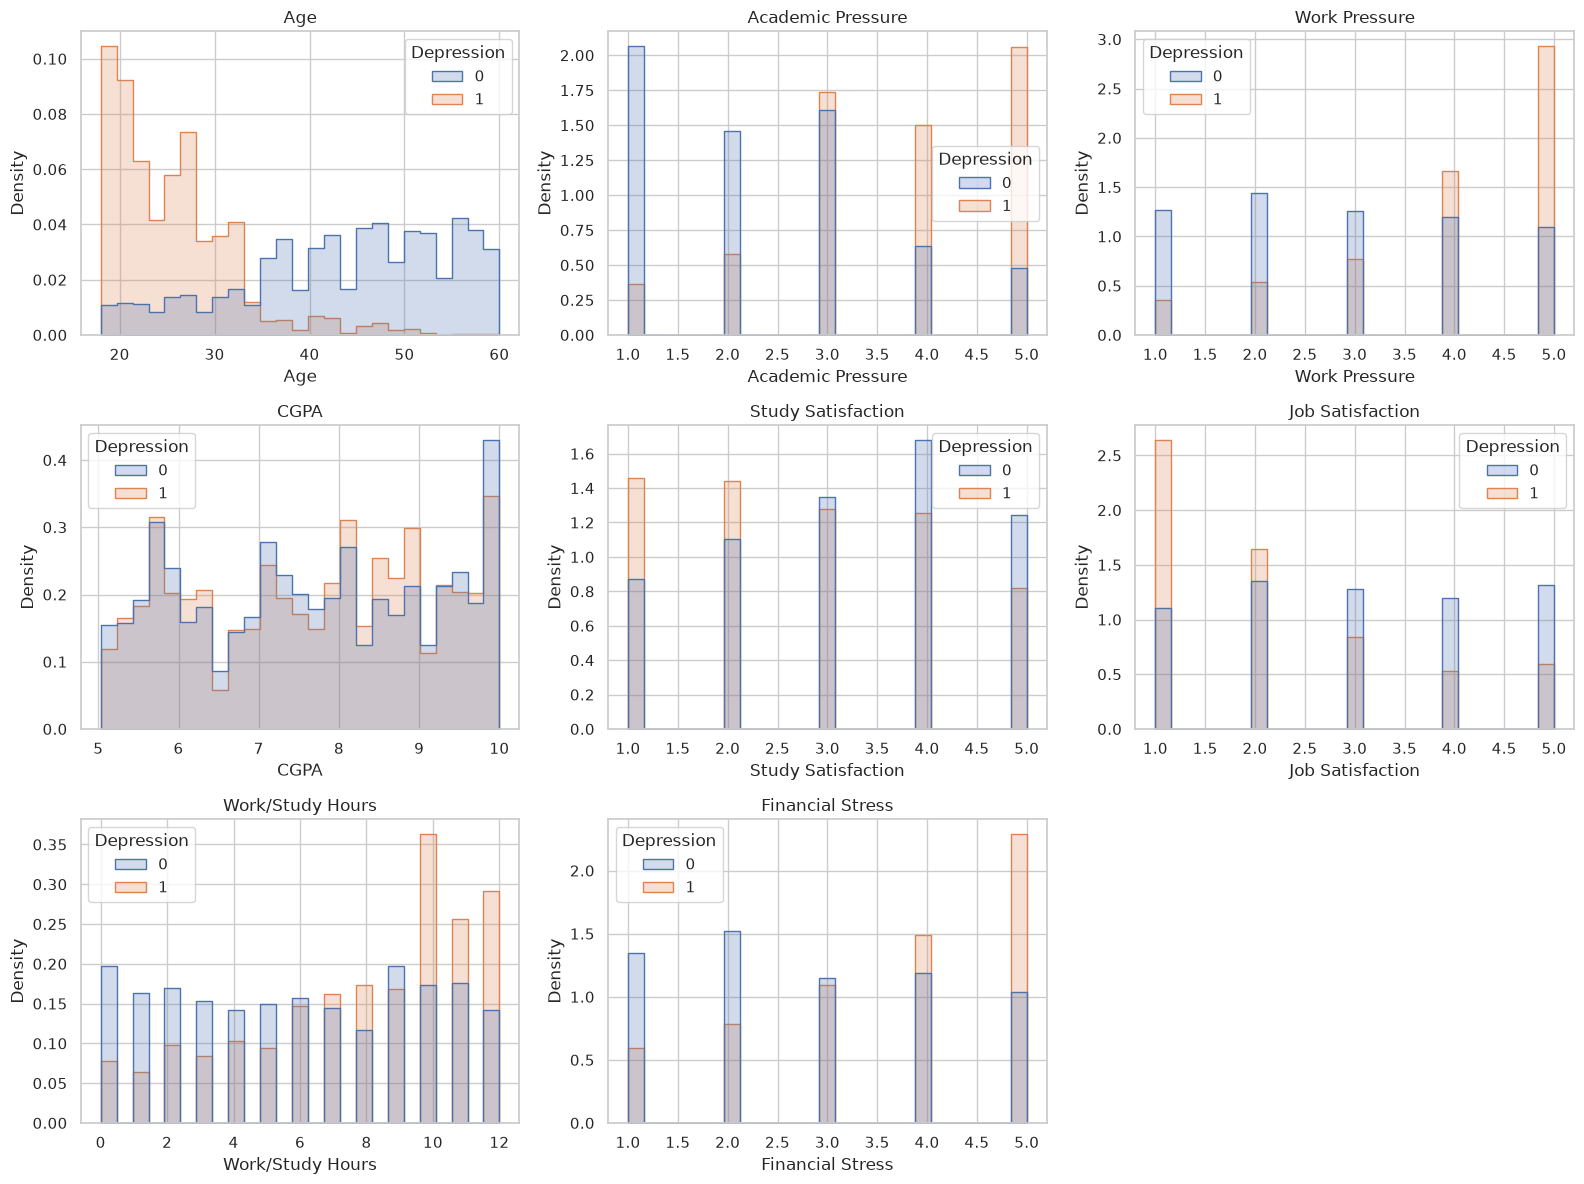

In [34]:
numeric_columns = [
    column for column in train.select_dtypes(include=np.number).columns
    if column not in {"id", TARGET}
]
display(train[numeric_columns].describe().T)

plot_sample = train.sample(min(50000, len(train)), random_state=RANDOM_STATE)
n_cols = 3
n_rows = int(np.ceil(len(numeric_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
for column, axis in zip(numeric_columns, np.asarray(axes).ravel()):
    sns.histplot(
        data=plot_sample,
        x=column,
        hue=TARGET,
        stat="density",
        common_norm=False,
        element="step",
        bins=25,
        ax=axis,
    )
    axis.set_title(column)
for axis in np.asarray(axes).ravel()[len(numeric_columns):]:
    axis.remove()
plt.tight_layout()
plt.show()

In [35]:
PLAUSIBLE_RANGES = {
    "Age": (18, 100),
    "Academic Pressure": (1, 5),
    "Work Pressure": (1, 5),
    "CGPA": (0, 10),
    "Study Satisfaction": (1, 5),
    "Job Satisfaction": (1, 5),
    "Work/Study Hours": (0, 24),
    "Financial Stress": (1, 5),
}

outlier_rows = []
for column in numeric_columns:
    values = train[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    plausible_min, plausible_max = PLAUSIBLE_RANGES[column]
    outlier_rows.append({
        "column": column,
        "min": values.min(),
        "max": values.max(),
        "iqr_outliers": int(((values < lower_iqr) | (values > upper_iqr)).sum()),
        "outside_plausible_range": int(((values < plausible_min) | (values > plausible_max)).sum()),
    })
display(pd.DataFrame(outlier_rows))

,column,min,max,iqr_outliers,outside_plausible_range
0,Age,18.00,60.0,0,0
1,Academic Pressure,1.00,5.0,0,0
2,Work Pressure,1.00,5.0,0,0
3,CGPA,5.03,10.0,0,0
4,Study Satisfaction,1.00,5.0,0,0
5,Job Satisfaction,1.00,5.0,0,0
6,Work/Study Hours,0.00,12.0,0,0
7,Financial Stress,1.00,5.0,0,0


## 7. Корреляции

Spearman-корреляция подходит для непрерывных и порядковых числовых признаков. Она показывает ассоциацию, но не причинность и не заменяет анализ категориальных переменных.

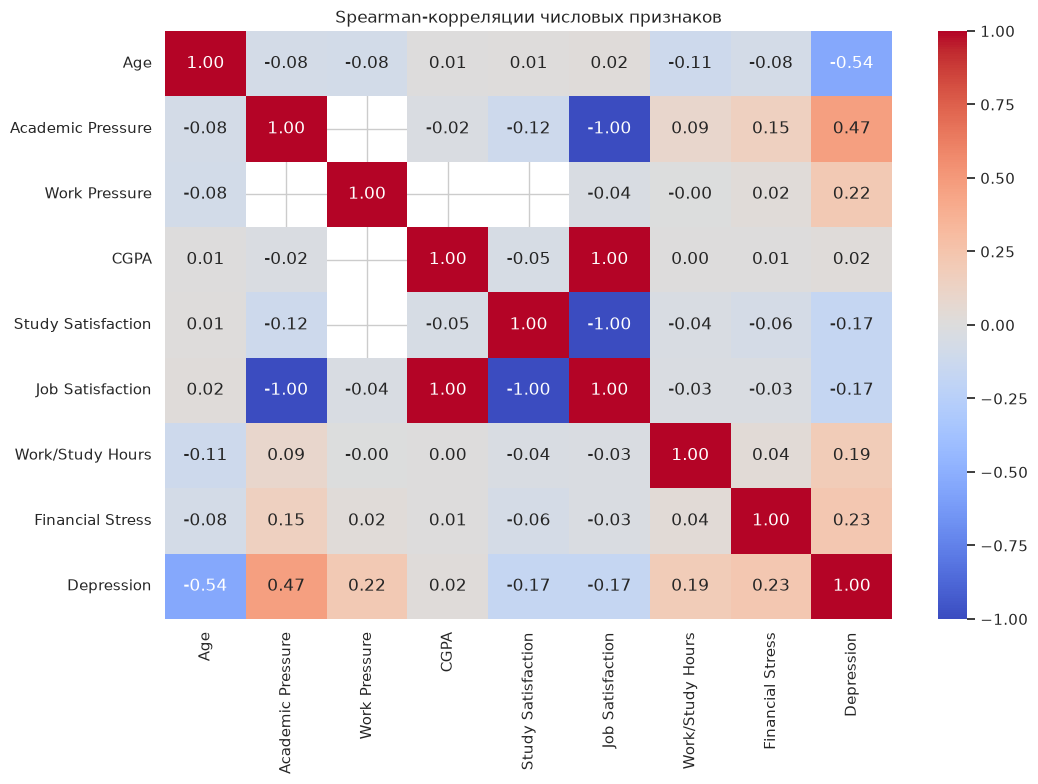

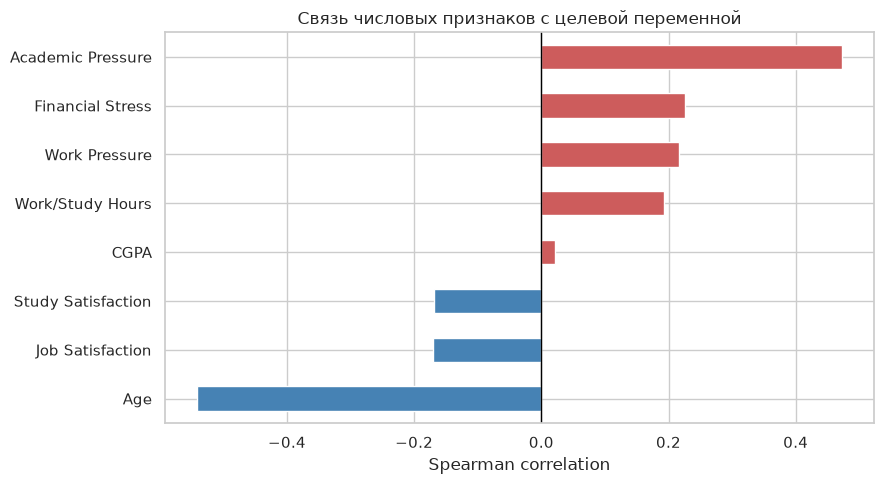

In [36]:
correlation_columns = numeric_columns + [TARGET]
spearman_corr = train[correlation_columns].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman-корреляции числовых признаков")
plt.tight_layout()
plt.show()

target_correlations = spearman_corr[TARGET].drop(TARGET).sort_values()
target_correlations.plot.barh(figsize=(9, 5), color=np.where(target_correlations >= 0, "indianred", "steelblue"))
plt.axvline(0, color="black", linewidth=1)
plt.title("Связь числовых признаков с целевой переменной")
plt.xlabel("Spearman correlation")
plt.tight_layout()
plt.show()

## 8. Сдвиг между train и test

Сильный сдвиг означает, что локальная валидация может плохо отражать качество на Kaggle test. Для числовых признаков используем standardized mean difference, для категориальных total variation distance.

In [14]:
def standardized_mean_difference(left: pd.Series, right: pd.Series) -> float:
    left = pd.to_numeric(left, errors="coerce")
    right = pd.to_numeric(right, errors="coerce")
    pooled_std = np.sqrt((left.var() + right.var()) / 2)
    if pooled_std == 0 or np.isnan(pooled_std):
        return 0.0
    return float(abs(left.mean() - right.mean()) / pooled_std)

numeric_drift = pd.DataFrame([
    {
        "column": column,
        "smd": standardized_mean_difference(train[column], kaggle_test[column]),
        "missing_train": train[column].isna().mean(),
        "missing_test": kaggle_test[column].isna().mean(),
    }
    for column in numeric_columns
]).sort_values("smd", ascending=False)
display(numeric_drift.style.format({"smd": "{:.3f}", "missing_train": "{:.2%}", "missing_test": "{:.2%}"}))

def total_variation_distance(left: pd.Series, right: pd.Series) -> float:
    left_share = left.fillna("<NA>").astype(str).value_counts(normalize=True)
    right_share = right.fillna("<NA>").astype(str).value_counts(normalize=True)
    categories = left_share.index.union(right_share.index)
    return float(0.5 * np.abs(left_share.reindex(categories, fill_value=0) - right_share.reindex(categories, fill_value=0)).sum())

categorical_drift = pd.DataFrame([
    {"column": column, "total_variation_distance": total_variation_distance(train[column], kaggle_test[column])}
    for column in categorical_columns
]).sort_values("total_variation_distance", ascending=False)
display(categorical_drift.style.format({"total_variation_distance": "{:.3f}"}))

,column,smd,missing_train,missing_test
1,Academic Pressure,0.012,80.17%,79.99%
3,CGPA,0.011,80.17%,79.99%
5,Job Satisfaction,0.010,19.84%,20.01%
2,Work Pressure,0.009,19.84%,20.02%
7,Financial Stress,0.007,0.00%,0.00%
0,Age,0.005,0.00%,0.00%
4,Study Satisfaction,0.004,80.17%,79.99%
6,Work/Study Hours,0.001,0.00%,0.00%


,column,total_variation_distance
1,City,0.011
3,Profession,0.011
6,Degree,0.008
4,Sleep Duration,0.004
0,Gender,0.004
2,Working Professional or Student,0.002
5,Dietary Habits,0.002
8,Family History of Mental Illness,0.001
7,Have you ever had suicidal thoughts ?,0.001


## 9. Подготовка после EDA

Выбираем минимальную подготовку, которая сохраняет смысл исходных признаков. Обоснование опирается на формат данных и устройство обучения. Новые эксперименты для выбора правил не проводились, улучшение качества модели не заявляем.

### 9.1. Фиксированная очистка

| Действие | Обоснование |
|---|---|
| Убираем Name, сохраняем id и Depression | Имя не является содержательным признаком. id нужен для контроля состава выборок, перед моделью он удаляется. |
| Убираем лишние пробелы в текстовых значениях | Разное оформление одного значения не должно создавать отдельные категории. |
| Проверяем формат длительности сна | Принимаем часы за сутки как рабочее допущение. Осмысленные интервалы от 0 до 24 часов сохраняем, обратные интервалы и посторонние строки переводим в Unknown. |
| Нормализуем Dietary Habits по небольшому словарю | Healthy, Moderate и Unhealthy сохраняются. More Healthy и Less Healthy оставляем отдельными значениями. Less than Healthy приводим к Less Healthy. |
| Объединяем понятные варианты Degree | B.Sc и BSc, BPharm и B.Pharm, BEd и B.Ed, MEd и M.Ed описывают одинаковые степени. Исправление написания должно предшествовать подсчету частот. |
| Сохраняем числовые значения и NaN | Не удаляем строки по IQR и не заменяем пропуски общей статистикой. |
| Сохраняем исходные признаки учебы, работы и роли | Общие Academic Data Available и Work Data Available не добавляем. Перед моделью уже предусмотрены индикаторы отдельных пропусков для LR/RF и структурные NaN для CatBoost/LightGBM. |


In [52]:
UNKNOWN_CATEGORY = "Unknown"
MISSING_CATEGORY = "Missing"
RARE_CATEGORY = "Rare"
DEGREE_ALIASES = {
    "bsc": "BSc", "b.sc": "BSc",
    "b.pharm": "B.Pharm", "bpharm": "B.Pharm",
    "b.ed": "B.Ed", "bed": "B.Ed",
    "m.ed": "M.Ed", "med": "M.Ed",
}


def normalize_category(value):
    if pd.isna(value):
        return pd.NA
    text = re.sub(r"\s+", " ", str(value).strip())
    return text if text else pd.NA


def normalize_degree(value):
    text = normalize_category(value)
    if pd.isna(text):
        return pd.NA
    return DEGREE_ALIASES.get(text.casefold(), text)


def classify_dietary_habits(value):
    text = normalize_category(value)
    if pd.isna(text):
        return pd.NA
    aliases = {
        "healthy": "Healthy", "moderate": "Moderate", "unhealthy": "Unhealthy",
        "more healthy": "More Healthy", "less healthy": "Less Healthy",
        "less than healthy": "Less Healthy",
    }
    return aliases.get(text.casefold(), UNKNOWN_CATEGORY)


def classify_sleep_duration(value):
    text = normalize_category(value)
    if pd.isna(text):
        return pd.NA
    text = text.casefold()
    aliases = {
        "less than 5 hours": "Less than 5 hours", "<5 hours": "Less than 5 hours",
        "more than 8 hours": "More than 8 hours", ">8 hours": "More than 8 hours",
    }
    if text in aliases:
        return aliases[text]
    match = re.fullmatch(r"(\d+)(?:\s*-\s*(\d+))?\s*hours?", text)
    if match is None:
        return UNKNOWN_CATEGORY
    lower = int(match.group(1))
    upper = int(match.group(2)) if match.group(2) is not None else lower
    if not 0 <= lower <= upper <= 24:
        return UNKNOWN_CATEGORY
    return f"{lower} hours" if lower == upper else f"{lower}-{upper} hours"


def prepare_after_eda(data):
    data = data.drop(columns=["Name", "Academic Data Available", "Work Data Available"], errors="ignore").copy()
    categorical = data.select_dtypes(include=["str", "object", "category"]).columns
    for column in categorical:
        data[column] = data[column].map(normalize_category)
    data["Sleep Duration"] = data["Sleep Duration"].map(classify_sleep_duration)
    data["Dietary Habits"] = data["Dietary Habits"].map(classify_dietary_habits)
    if "Degree" in data:
        data["Degree"] = data["Degree"].map(normalize_degree)
    return data


### 9.2. Проверяем таблицы замен

Показываем исходное значение, результат очистки и число строк. Это проверка содержания данных, а не эксперимент с качеством модели. Для City и Profession выполняется только очистка пробелов.


In [53]:
normalizers = {
    "Sleep Duration": classify_sleep_duration,
    "Dietary Habits": classify_dietary_habits,
    "Degree": normalize_degree,
}
for column, normalizer in normalizers.items():
    mapping = train[column].value_counts(dropna=False).rename("count").reset_index()
    mapping["prepared"] = mapping[column].map(normalizer)
    print(column)
    display(mapping)


Sleep Duration


,Sleep Duration,count,prepared
0,Less than 5 hours,38784,Less than 5 hours
1,7-8 hours,36969,7-8 hours
2,More than 8 hours,32726,More than 8 hours
3,5-6 hours,32142,5-6 hours
4,3-4 hours,12,3-4 hours
5,6-7 hours,8,6-7 hours
6,4-5 hours,7,4-5 hours
7,4-6 hours,5,4-6 hours
8,2-3 hours,5,2-3 hours
9,6-8 hours,4,6-8 hours


Dietary Habits


,Dietary Habits,count,prepared
0,Moderate,49705,Moderate
1,Unhealthy,46227,Unhealthy
2,Healthy,44741,Healthy
3,NaN,4,NaN
4,Yes,2,Unknown
5,More Healthy,2,More Healthy
6,No,2,Unknown
7,Pratham,1,Unknown
8,BSc,1,Unknown
9,Gender,1,Unknown


Degree


,Degree,count,prepared
0,Class 12,14729,Class 12
1,B.Ed,11691,B.Ed
2,B.Arch,8742,B.Arch
3,B.Com,8113,B.Com
4,B.Pharm,5856,B.Pharm
...,...,...,...
111,LCA,1,LCA
112,B B.Com,1,B B.Com
113,RCA,1,RCA
114,Mihir,1,Mihir


### 9.3. Редкие категории оставляем до модели

City, Profession и Degree имеют длинный хвост категорий с единичными наблюдениями. Сама редкость не означает ошибку: например, редкая степень M.Arch остается осмысленным значением.

В data/preprocessed сохраняем такие значения. Перед моделью используем рабочий порог rare_min_count=5. Категория с 1-4 наблюдениями не дает достаточной опоры для самостоятельной оценки эффекта, поэтому объединяем такие значения в Rare. Порог выбран как простой способ ограничения редкого хвоста, его оптимальность не установлена.

На пересозданном train из 112555 строк после нормализации получена следующая описательная статистика.

| Столбец | Категорий с частотой меньше 5 | Строк с такими значениями |
|---|---:|---:|
| City | 61 | 81 |
| Profession | 25 | 37 |
| Degree | 68 | 83 |

Редкий хвост занимает менее 0.1% строк каждого из этих столбцов. Нормализация Degree сохранила смысл девяти строк, которые раньше попадали бы в редкий хвост. Эти числа описывают данные и не измеряют качество модели.

Различаем три ситуации:

- Missing - исходный пропуск, в частности отсутствие профессии у части студентов.
- Rare - значение встречалось в обучающей части, но реже заданного порога.
- Unknown - некорректное значение или категория, которой не было в обучающей части.

Эта обработка применяется к категориальным признакам внутри преобразователя модели. Частоты и список известных значений обучаются только на train-fold, затем применяются к проверочному фолду


### 9.4. Сохраняем состав train и val

Используем прежние 20% val, seed=56 и стратификацию по Depression.


In [54]:
train_raw, val_raw = train_test_split(
    train, test_size=0.20, random_state=RANDOM_STATE, stratify=train[TARGET],
)
features = [column for column in train if column not in ["id", "Name", TARGET]]
without_duplicates = pd.concat([val_raw, train_raw]).drop_duplicates(subset=features)
train_raw = without_duplicates[without_duplicates["id"].isin(train_raw["id"])].copy()

for name, part in [("train", train_raw), ("val", val_raw)]:
    previous_path = PREPROCESSED_DIR / f"{name}.csv"
    if previous_path.exists():
        previous = pd.read_csv(previous_path, usecols=["id", TARGET])
        if not part[["id", TARGET]].reset_index(drop=True).equals(previous):
            raise ValueError(f"Изменился состав или порядок {name}. Нужно отдельно согласовать новое разбиение.")

train_preprocessed = prepare_after_eda(train_raw)
val_preprocessed = prepare_after_eda(val_raw)
test_preprocessed = prepare_after_eda(kaggle_test)

display(pd.DataFrame({
    "rows": [len(train_preprocessed), len(val_preprocessed), len(test_preprocessed)],
    "target_rate": [train_preprocessed[TARGET].mean(), val_preprocessed[TARGET].mean(), np.nan],
}, index=["train", "val", "kaggle_test"]))

rare_summary = []
for column in ["City", "Profession", "Degree"]:
    counts = train_preprocessed[column].dropna().value_counts()
    rare = counts[counts < 5]
    rare_summary.append({
        "column": column, "categories": len(counts),
        "categories_lt_5": len(rare), "rows_lt_5": int(rare.sum()),
    })
display(pd.DataFrame(rare_summary))


,rows,target_rate
train,112555,0.181689
val,28140,0.181699
kaggle_test,93800,NaN


,column,categories,categories_lt_5,rows_lt_5
0,City,91,61,81
1,Profession,61,25,37
2,Degree,95,68,83


In [55]:
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
train_preprocessed.to_csv(PREPROCESSED_DIR / "train.csv", index=False)
val_preprocessed.to_csv(PREPROCESSED_DIR / "val.csv", index=False)
test_preprocessed.to_csv(PREPROCESSED_DIR / "test.csv", index=False)

print("Подготовленные данные сохранены в", PREPROCESSED_DIR)
print("Числовые пропуски в train:")
display(train_preprocessed[numeric_columns].isna().sum())


Подготовленные данные сохранены в data/preprocessed
Числовые пропуски в train:


Age                       0
Academic Pressure     90234
Work Pressure         22339
CGPA                  90233
Study Satisfaction    90234
Job Satisfaction      22332
Work/Study Hours          0
Financial Stress          4
dtype: int64

**Вывод.** В preprocessed сохраняем осмысленные категории и числовые пропуски. Исправляем оформление и понятные синонимы, а интервалы сна оставляем с исходными границами. Редкие категории объединяются только внутри модели, отдельно от пропусков и неизвестных значений.

Обоснование этих действий связано с сохранением информации и корректным разделением обучения и оценки. Они не доказывают улучшения Accuracy. Новые CSV относятся к новой подготовке, прежние метрики и обученные модели относятся к старой версии данных. После изменения CSV их нужно зарегистрировать через dvc add data/preprocessed.

Состав train/val сохраняется. EDA ранее изучил весь размеченный набор, поэтому val остается исследовательской оценкой.
